###Libraries

In [1]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import json
import matplotlib.patches as patches
from datasets import load_from_disk
import pandas as pd

In [3]:
PROJECT_DIR = '/content/drive/MyDrive/DocFusion'
SROIE_TRAIN = f'{PROJECT_DIR}/data/SROIE2019/train'
SROIE_TEST  = f'{PROJECT_DIR}/data/SROIE2019/test'
CORD_DIR    = f'{PROJECT_DIR}/data/cord'
FINDITAGAIN_DIR = f'{PROJECT_DIR}/data/findit2'

###Inspection of SROIE

Sample: X00016469612


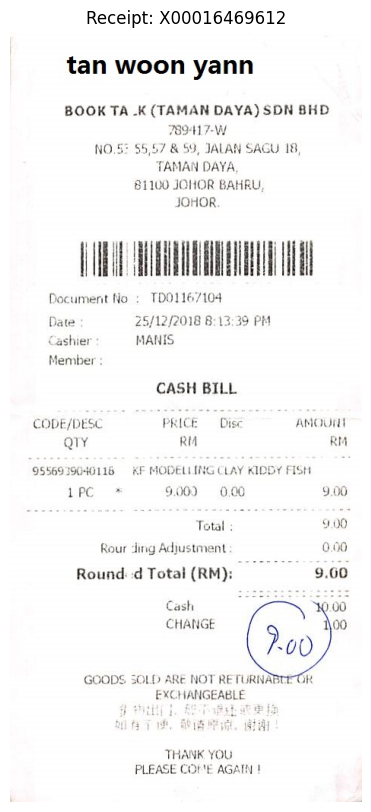


 BOX FILE (words + coordinates):
72,25,326,25,326,64,72,64,TAN WOON YANN
50,82,440,82,440,121,50,121,BOOK TA .K(TAMAN DAYA) SDN BND
205,121,285,121,285,139,205,139,789417-W
110,144,383,144,383,163,110,163,NO.53 55,57 & 59, JALAN SAGU 18,
192,169,299,169,299,187,192,187,TAMAN DAYA,
162,193,334,193,334,211,162,211,81100 JOHOR BAHRU,
217,216,275,216,275,233,217,233,JOHOR.
50,342,279,342,279,359,50,359,DOCUMENT NO : TD01167104
50,372,96,372,96,390,50,390,DATE:
165,372,342,372,342,389,165,389,25/12/2018 8:13:39 PM

ENTITIES FILE (ground truth):
{
  "company": "BOOK TA .K (TAMAN DAYA) SDN BHD",
  "date": "25/12/2018",
  "address": "NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 81100 JOHOR BAHRU, JOHOR.",
  "total": "9.00"
}


In [ ]:

img_files = sorted(os.listdir(f'{SROIE_TRAIN}/img'))
sample_name = img_files[0].replace('.jpg', '')

print(f"Sample: {sample_name}")


img = Image.open(f'{SROIE_TRAIN}/img/{sample_name}.jpg')
plt.figure(figsize=(6, 10))
plt.imshow(img)
plt.title(f'Receipt: {sample_name}')
plt.axis('off')
plt.show()


print("\n BOX FILE (words + coordinates):")
with open(f'{SROIE_TRAIN}/box/{sample_name}.txt', 'r') as f:
    lines = f.readlines()
    for line in lines[:10]:
        print(line.strip())


print("\nENTITIES FILE (ground truth):")
with open(f'{SROIE_TRAIN}/entities/{sample_name}.txt', 'r') as f:
    entity = json.load(f)
    print(json.dumps(entity, indent=2))

In [ ]:
def load_entities(entities_dir):
    records = []
    for fname in os.listdir(entities_dir):
        if fname.endswith('.txt'):
            fpath = os.path.join(entities_dir, fname)
            try:
                with open(fpath, 'r') as f:
                    data = json.load(f)
                    data['id'] = fname.replace('.txt', '')
                    records.append(data)
            except:
                pass
    return pd.DataFrame(records)

train_df = load_entities(f'{SROIE_TRAIN}/entities')
test_df  = load_entities(f'{SROIE_TEST}/entities')

print(f"Train samples: {len(train_df)}")
print(f"Test samples:  {len(test_df)}")
print(f"\nColumns: {train_df.columns.tolist()}")
print(f"\nSample rows:")
train_df.head()

Train samples: 626
Test samples:  347

Columns: ['company', 'date', 'address', 'total', 'id']

Sample rows:


,company,date,address,total,id
0,TK DIVISION KITCHEN SDN BHD,17/1/2018,"19-1. JALAN MALINJA 2, TAMAN BUNGA RAYA, 53100...",RM 29.70,X51005719814
1,LAVENDER CONFECTIONERY & BAKERY S/B,17/06/2018,"LOT G29 & G30, AEON MALL TEBRAU CITY, NO. 1, J...",26.50,X51007846412
2,SANYU STATIONERY SHOP,06/09/2017,"NO. 31G&33G, JALAN SETIA INDAH X ,U13/X 40170 ...",8.70,X51007339132
3,PASARAYA CINWA SDN BHD,15/06/2018,"NO.6,8, 10& 12 JALAN PERMAS 4/3 BANDAR BARU PE...",14.20,X51007846350
4,AEON CO. (M) BHD,12/03/2018,"3RD FLR, AEON TAMAN MALURI SC JLN JEJAKA, TAMA...",42.50,X51005757248


In [ ]:
train_df

,company,date,address,total,id
0,TK DIVISION KITCHEN SDN BHD,17/1/2018,"19-1. JALAN MALINJA 2, TAMAN BUNGA RAYA, 53100...",RM 29.70,X51005719814
1,LAVENDER CONFECTIONERY & BAKERY S/B,17/06/2018,"LOT G29 & G30, AEON MALL TEBRAU CITY, NO. 1, J...",26.50,X51007846412
2,SANYU STATIONERY SHOP,06/09/2017,"NO. 31G&33G, JALAN SETIA INDAH X ,U13/X 40170 ...",8.70,X51007339132
3,PASARAYA CINWA SDN BHD,15/06/2018,"NO.6,8, 10& 12 JALAN PERMAS 4/3 BANDAR BARU PE...",14.20,X51007846350
4,AEON CO. (M) BHD,12/03/2018,"3RD FLR, AEON TAMAN MALURI SC JLN JEJAKA, TAMA...",42.50,X51005757248
...,...,...,...,...,...
621,BOOK TA .K (TAMAN DAYA) SDN BHD,25/12/2018,"NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 8...",9.00,X00016469612
622,99 SPEED MART S/B,24-01-18,"LOT P.T. 2811, JALAN ANGSA, TAMAN BERKELEY 411...",2.50,X51005361950
623,BROADVIEW MARKETING SDN BHD,15/05/2017,"NO. 9-G, JALAN DINAR D U3/D TAMAN SUBANG PERDA...",4.70,X51006388082
624,MR. D.I.Y. (KUCHAI) SDN BHD,12-03-18,"LOT 1851-A & 1851-B, JALAN KPB 6, KAWASAN PERI...",45.00,X51005757273


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 626 entries, 0 to 625
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   company  626 non-null    object
 1   date     626 non-null    object
 2   address  625 non-null    object
 3   total    626 non-null    object
 4   id       626 non-null    object
dtypes: object(5)
memory usage: 24.6+ KB


In [ ]:
train_df.isna().sum()

,0
company,0
date,0
address,1
total,0
id,0


In [ ]:
train_df = train_df.dropna()

In [ ]:
train_df.isna().sum()

,0
company,0
date,0
address,0
total,0
id,0


In [ ]:
train_df

,company,date,address,total,id
0,TK DIVISION KITCHEN SDN BHD,17/1/2018,"19-1. JALAN MALINJA 2, TAMAN BUNGA RAYA, 53100...",RM 29.70,X51005719814
1,LAVENDER CONFECTIONERY & BAKERY S/B,17/06/2018,"LOT G29 & G30, AEON MALL TEBRAU CITY, NO. 1, J...",26.50,X51007846412
2,SANYU STATIONERY SHOP,06/09/2017,"NO. 31G&33G, JALAN SETIA INDAH X ,U13/X 40170 ...",8.70,X51007339132
3,PASARAYA CINWA SDN BHD,15/06/2018,"NO.6,8, 10& 12 JALAN PERMAS 4/3 BANDAR BARU PE...",14.20,X51007846350
4,AEON CO. (M) BHD,12/03/2018,"3RD FLR, AEON TAMAN MALURI SC JLN JEJAKA, TAMA...",42.50,X51005757248
...,...,...,...,...,...
621,BOOK TA .K (TAMAN DAYA) SDN BHD,25/12/2018,"NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 8...",9.00,X00016469612
622,99 SPEED MART S/B,24-01-18,"LOT P.T. 2811, JALAN ANGSA, TAMAN BERKELEY 411...",2.50,X51005361950
623,BROADVIEW MARKETING SDN BHD,15/05/2017,"NO. 9-G, JALAN DINAR D U3/D TAMAN SUBANG PERDA...",4.70,X51006388082
624,MR. D.I.Y. (KUCHAI) SDN BHD,12-03-18,"LOT 1851-A & 1851-B, JALAN KPB 6, KAWASAN PERI...",45.00,X51005757273


In [ ]:
test_df.isna().sum()

,0
company,0
date,0
address,0
total,0
id,0


In [ ]:
import re

def clean_total(val):
    if pd.isna(val):
        return None
    val = str(val).replace(',', '.').strip()
    val = re.sub(r'[^\d.]', '', val)
    try:
        return float(val)
    except:
        return None

train_df['total_clean'] = train_df['total'].apply(clean_total)
test_df['total_clean']  = test_df['total'].apply(clean_total)

print("✅ Total values cleaned!")
print(train_df[['total', 'total_clean']].head(10))

✅ Total values cleaned!
      total  total_clean
0  RM 29.70         29.7
1     26.50         26.5
2      8.70          8.7
3     14.20         14.2
4     42.50         42.5
5      3.70          3.7
6     52.40         52.4
7     $8.20          8.2
8     $8.70          8.7
9  RM 12.50         12.5


/tmp/ipykernel_226/2453159387.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['total_clean'] = train_df['total'].apply(clean_total)


In [ ]:
test_df

,company,date,address,total,id,total_clean
0,URBAN IDEA SDN BHD,14/02/2018,"A-G-06, DATARAN GLOMAC, JALAN SS6/5A, PUSAT BA...",RM11.90,X51005745244,11.90
1,SIN LIANHAP SDN BHD,05/02/2018,"LOT 13, JALAN IPOH, KG BATU 30, ULU YAM LAMA 4...",7.30,X51005230621,7.30
2,SEGI CASH & CARRY SDN. BHD.,06 JAN 2018,"PT17920 SEK U9, SHAH ALAM",674.00,X51005763999,674.00
3,118 MJ MOOKATA HOUSE,11-06-2018,"NO.7G,JALAN PERMAS 11, BANDAR BARU PERMAS JAYA...",102.40,X51007846361,102.40
4,MR. D. I. Y. (KUCHAI) SDN BHD,19-03-18,"LOT 1851-A & 1851-B, JALAN KPB 6, KAWASAN PERI...",11.90,X51005719898,11.90
...,...,...,...,...,...,...
342,KEDAI PAPAN YEW CHUAN,21/03/2018,"LOT 276 JALAN BANTING 43800 DENGKIL, SELANGOR.",144.16,X51005724611,144.16
343,ALI BABA INTERNATIONAL SDN BHD,19-02-2018,"PUBLIKA SHOPPING GALLERY LOT 26-27 ,LEVEL G2,J...",23.80,X51005719857,23.80
344,99 SPEED MART S/B,28-01-18,"LOT P.T. 2811, JALAN ANGSA, TAMAN BERKELEY 411...",98.90,X51005764161,98.90
345,KEDAI PAPAN YEW CHUAN,07/03/2018,"LOT 276 JALAN BANTING 43800 DENGKIL, SELANGOR.",91.16,X51005724622,91.16


In [ ]:
train_df = train_df.drop(columns=['total'])
test_df = test_df.drop(columns=['total'])

In [ ]:
train_df.head(5)

,company,date,address,id,total_clean
0,TK DIVISION KITCHEN SDN BHD,17/1/2018,"19-1. JALAN MALINJA 2, TAMAN BUNGA RAYA, 53100...",X51005719814,29.7
1,LAVENDER CONFECTIONERY & BAKERY S/B,17/06/2018,"LOT G29 & G30, AEON MALL TEBRAU CITY, NO. 1, J...",X51007846412,26.5
2,SANYU STATIONERY SHOP,06/09/2017,"NO. 31G&33G, JALAN SETIA INDAH X ,U13/X 40170 ...",X51007339132,8.7
3,PASARAYA CINWA SDN BHD,15/06/2018,"NO.6,8, 10& 12 JALAN PERMAS 4/3 BANDAR BARU PE...",X51007846350,14.2
4,AEON CO. (M) BHD,12/03/2018,"3RD FLR, AEON TAMAN MALURI SC JLN JEJAKA, TAMA...",X51005757248,42.5


In [ ]:
train_df

,company,date,address,id,total_clean
0,TK DIVISION KITCHEN SDN BHD,17/1/2018,"19-1. JALAN MALINJA 2, TAMAN BUNGA RAYA, 53100...",X51005719814,29.7
1,LAVENDER CONFECTIONERY & BAKERY S/B,17/06/2018,"LOT G29 & G30, AEON MALL TEBRAU CITY, NO. 1, J...",X51007846412,26.5
2,SANYU STATIONERY SHOP,06/09/2017,"NO. 31G&33G, JALAN SETIA INDAH X ,U13/X 40170 ...",X51007339132,8.7
3,PASARAYA CINWA SDN BHD,15/06/2018,"NO.6,8, 10& 12 JALAN PERMAS 4/3 BANDAR BARU PE...",X51007846350,14.2
4,AEON CO. (M) BHD,12/03/2018,"3RD FLR, AEON TAMAN MALURI SC JLN JEJAKA, TAMA...",X51005757248,42.5
...,...,...,...,...,...
621,BOOK TA .K (TAMAN DAYA) SDN BHD,25/12/2018,"NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 8...",X00016469612,9.0
622,99 SPEED MART S/B,24-01-18,"LOT P.T. 2811, JALAN ANGSA, TAMAN BERKELEY 411...",X51005361950,2.5
623,BROADVIEW MARKETING SDN BHD,15/05/2017,"NO. 9-G, JALAN DINAR D U3/D TAMAN SUBANG PERDA...",X51006388082,4.7
624,MR. D.I.Y. (KUCHAI) SDN BHD,12-03-18,"LOT 1851-A & 1851-B, JALAN KPB 6, KAWASAN PERI...",X51005757273,45.0


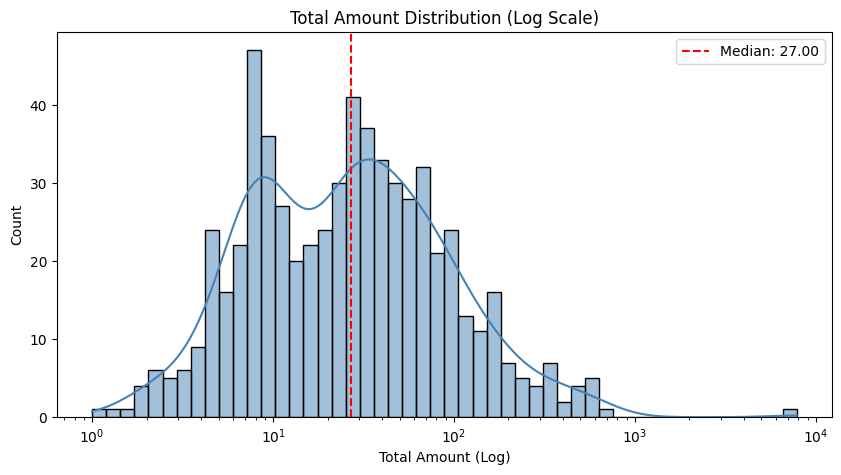

count     623.000000
mean       67.821734
std       324.624494
min         1.000000
25%         8.925000
50%        27.000000
75%        60.450000
max      7838.800000
Name: total_clean, dtype: float64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.histplot(train_df['total_clean'].dropna(), kde=True, bins=50, color='steelblue', log_scale=True)

plt.title('Total Amount Distribution (Log Scale)')
plt.xlabel('Total Amount (Log)')
plt.axvline(train_df['total_clean'].median(), color='red', ls='--', label=f"Median: {train_df['total_clean'].median():.2f}")
plt.legend()
plt.show()


print(train_df['total_clean'].describe())

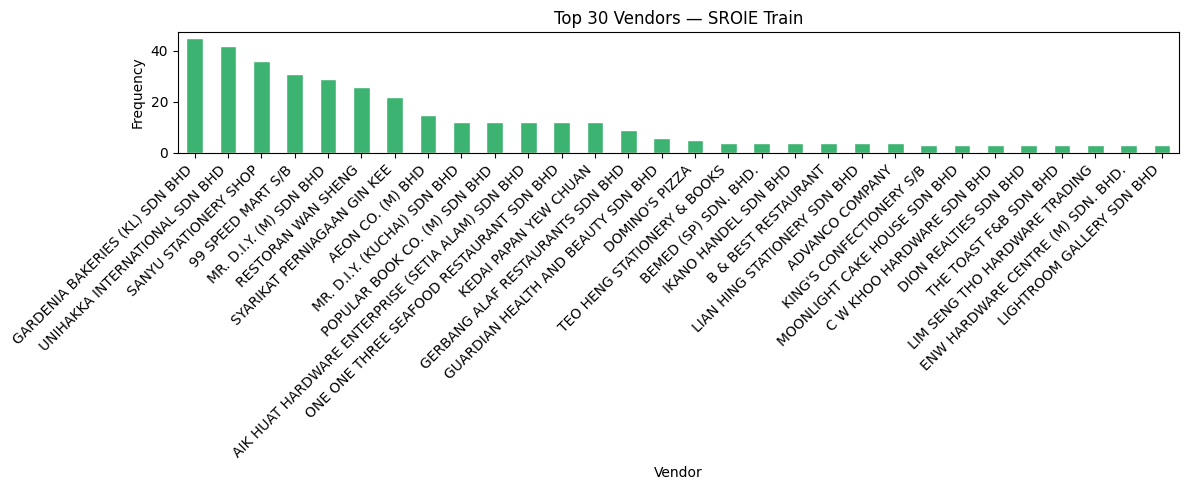


Total unique vendors: 235


In [ ]:
top_vendors = train_df['company'].value_counts().head(30)

plt.figure(figsize=(12, 5))
top_vendors.plot(kind='bar', color='mediumseagreen', edgecolor='white')
plt.title('Top 30 Vendors — SROIE Train')
plt.xlabel('Vendor')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\nTotal unique vendors: {train_df['company'].nunique()}")

 Outlier Threshold (IQR Method): 137.74
 Suspicious high-total receipts: 57
------------------------------
               id                       company         date  total_clean
93   X51005806678     KAISON FURNISHING SDN BHD     29-01-18      7838.80
306  X51006335552            YONG SOON FATT S/B     6/2/2017       758.70
422  X51006387847          BEMED (SP) SDN. BHD.  15/APR/2017       635.00
585  X51006556831      PINGHWAI TRADING SDN BHD   30/09/2017       616.60
226  X51005663297      BEYOND BROTHERS HARDWARE   14/03/2018       599.45
50   X51005442361  TIMELESS KITCHENETTE SDN BHD   2018-03-23       593.10
283  X51005568913          IKANO HANDEL SDN BHD     27/07/17       538.00
51   X51008145505               KT WONG TRADING   09/06/2018       489.30
387  X51006913019              AEON CO. (M) BHD   11/05/2018       476.80
562  X51007846368      GRANDMA HOMES RESTAURANT   13/06/2018       473.30


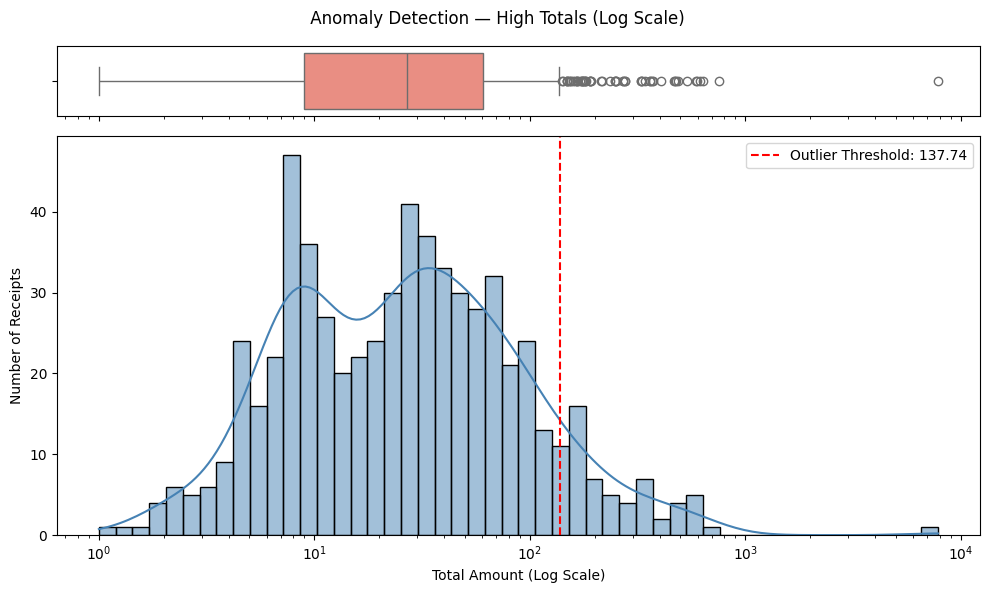

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


Q1 = train_df['total_clean'].quantile(0.25)
Q3 = train_df['total_clean'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR


outliers = train_df[train_df['total_clean'] > upper_bound]


print(f" Outlier Threshold (IQR Method): {upper_bound:.2f}")
print(f" Suspicious high-total receipts: {len(outliers)}")
print("-" * 30)
print(outliers[['id', 'company', 'date', 'total_clean']].sort_values(by='total_clean', ascending=False).head(10))


fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, figsize=(10, 6),
                                     gridspec_kw={"height_ratios": (.15, .85)})


sns.boxplot(x=train_df['total_clean'], ax=ax_box, color='salmon')
ax_box.set_xscale("log")


sns.histplot(train_df['total_clean'], ax=ax_hist, bins=50, kde=True, color='steelblue', log_scale=True)


ax_hist.axvline(upper_bound, color='red', ls='--', label=f'Outlier Threshold: {upper_bound:.2f}')

plt.suptitle(' Anomaly Detection — High Totals (Log Scale)')
ax_hist.set_xlabel('Total Amount (Log Scale)')
ax_hist.set_ylabel('Number of Receipts')
ax_hist.legend()

plt.tight_layout()
plt.show()

###Inspection of CORD

CORD splits: DatasetDict({
    train: Dataset({
        features: ['image', 'ground_truth'],
        num_rows: 800
    })
    validation: Dataset({
        features: ['image', 'ground_truth'],
        num_rows: 100
    })
    test: Dataset({
        features: ['image', 'ground_truth'],
        num_rows: 100
    })
})
CORD train size: 800
CORD features: {'image': Image(mode=None, decode=True), 'ground_truth': Value('string')}


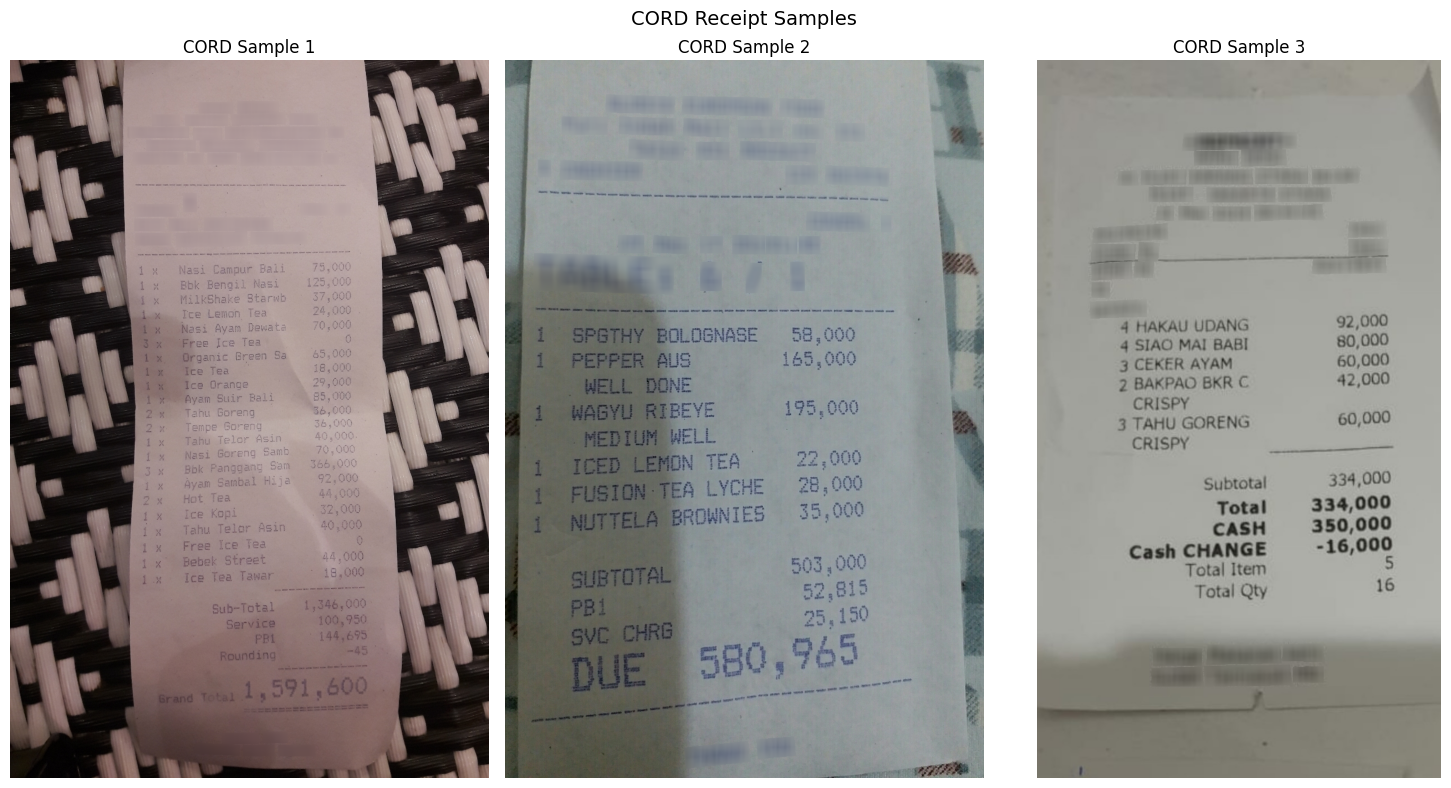

In [ ]:
cord = load_from_disk(CORD_DIR)

print(f"CORD splits: {cord}")
print(f"CORD train size: {len(cord['train'])}")
print(f"CORD features: {cord['train'].features}")


fig, axes = plt.subplots(1, 3, figsize=(15, 8))
for i, ax in enumerate(axes):
    img = cord['train'][i]['image']
    ax.imshow(img)
    ax.set_title(f'CORD Sample {i+1}')
    ax.axis('off')
plt.suptitle('CORD Receipt Samples', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
import random
from pprint import pprint

random_int = random.randint(0, 800)
pprint(cord['train'][random_int])

{'ground_truth': '{"gt_parse": {"menu": [{"nm": "Thai Tea - ICE", "cnt": "1", '
                 '"price": "20.000"}, {"nm": "Green Tea ICE", "cnt": "1", '
                 '"price": "22.000"}, {"nm": "Thai Coffee ICE", "cnt": "1", '
                 '"price": "20.000"}], "total": {"total_price": "62.000", '
                 '"cashprice": "62.000", "changeprice": "0"}}, "meta": '
                 '{"version": "2.0.0", "split": "train", "image_id": 422, '
                 '"image_size": {"width": 576, "height": 864}}, "valid_line": '
                 '[{"words": [{"quad": {"x2": 102, "y3": 542, "x3": 102, "y4": '
                 '542, "x1": 62, "y1": 520, "x4": 62, "y2": 520}, "is_key": 0, '
                 '"row_id": 2195296, "text": "Thai"}, {"quad": {"x2": 138, '
                 '"y3": 540, "x3": 138, "y4": 540, "x1": 104, "y1": 520, "x4": '
                 '104, "y2": 520}, "is_key": 0, "row_id": 2195296, "text": '
                 '"Tea"}, {"quad": {"x2": 154, "y3": 536, "x3": 

###Inspection of Find-it-Again

In [ ]:
train_labels = pd.read_csv('/content/drive/MyDrive/DocFusion/data/findit2/train.txt')
val_labels   = pd.read_csv('/content/drive/MyDrive/DocFusion/data/findit2/val.txt')
test_labels  = pd.read_csv('/content/drive/MyDrive/DocFusion/data/findit2/test.txt')

print("Train Labels:")
print(train_labels['forged'].value_counts())
print(f"\nVal Labels:")
print(val_labels['forged'].value_counts())
print(f"\nTest Labels:")
print(test_labels['forged'].value_counts())

Train Labels:
forged
0    483
1     94
Name: count, dtype: int64

Val Labels:
forged
0    159
1     34
Name: count, dtype: int64

Test Labels:
forged
0    183
1     35
Name: count, dtype: int64


In [5]:
train_labels = pd.read_csv(f'{FINDITAGAIN_DIR}/train.txt')
val_labels   = pd.read_csv(f'{FINDITAGAIN_DIR}/val.txt')
test_labels  = pd.read_csv(f'{FINDITAGAIN_DIR}/test.txt')

print("✅ Find-It-Again labels loaded!")
print(f"\nColumns: {train_labels.columns.tolist()}")
print(f"\nSample rows:")
train_labels.head()

✅ Find-It-Again labels loaded!

Columns: ['image', 'digital annotation', 'handwritten annotation', 'forged', 'forgery annotations']

Sample rows:


,image,digital annotation,handwritten annotation,forged,forgery annotations
0,X00016469622.png,1,1,1,"{'filename': 'X00016469622.png', 'size': 23072..."
1,X00016469623.png,1,1,0,0
2,X00016469670.png,1,1,0,0
3,X00016469671.png,1,1,0,0
4,X00016469672.png,1,1,0,0


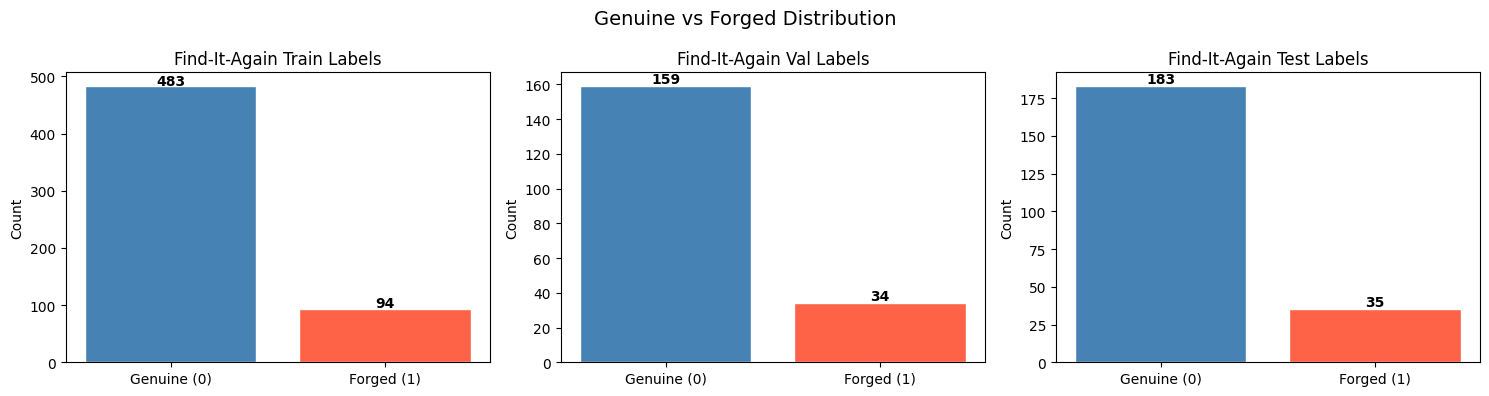


⚠️  Class Imbalance:
Genuine: 483 (83.7%)
Forged:  94 (16.3%)


In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (df, title) in zip(axes, [
    (train_labels, 'Train'),
    (val_labels,   'Val'),
    (test_labels,  'Test')
]):
    counts = df['forged'].value_counts()
    ax.bar(['Genuine (0)', 'Forged (1)'],
           [counts.get(0, 0), counts.get(1, 0)],
           color=['steelblue', 'tomato'],
           edgecolor='white')
    ax.set_title(f'Find-It-Again {title} Labels')
    ax.set_ylabel('Count')
    for i, v in enumerate([counts.get(0, 0), counts.get(1, 0)]):
        ax.text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.suptitle('Genuine vs Forged Distribution', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\n⚠️  Class Imbalance:")
print(f"Genuine: {train_labels['forged'].value_counts()[0]} ({train_labels['forged'].value_counts()[0]/len(train_labels)*100:.1f}%)")
print(f"Forged:  {train_labels['forged'].value_counts()[1]} ({train_labels['forged'].value_counts()[1]/len(train_labels)*100:.1f}%)")

/tmp/ipykernel_161/240293534.py:22: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_161/240293534.py:22: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


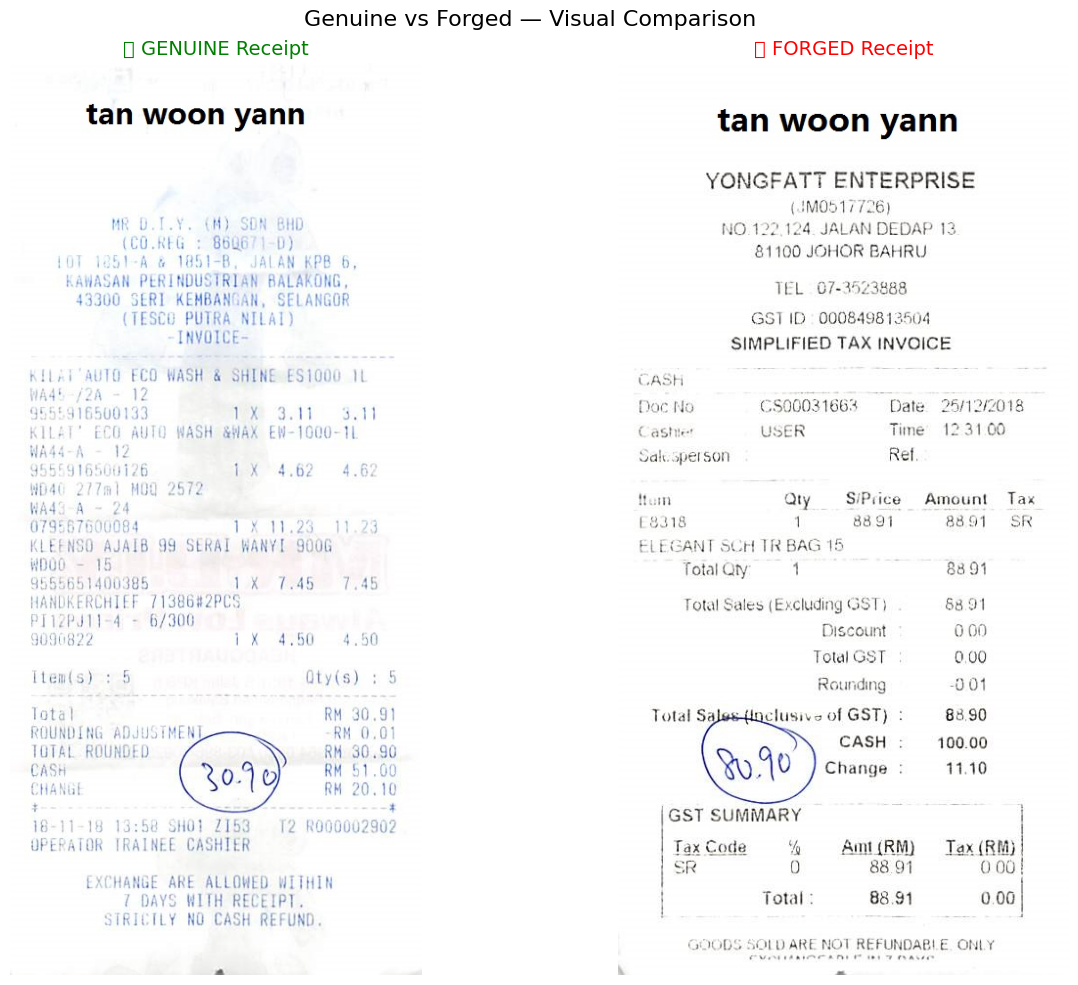

In [7]:
from PIL import Image
import matplotlib.pyplot as plt

# Get one genuine and one forged sample
genuine_samples = train_labels[train_labels['forged'] == 0]['image'].values
forged_samples  = train_labels[train_labels['forged'] == 1]['image'].values

genuine_img_path = f'{FINDITAGAIN_DIR}/train/{genuine_samples[0]}'
forged_img_path  = f'{FINDITAGAIN_DIR}/train/{forged_samples[0]}'

fig, axes = plt.subplots(1, 2, figsize=(14, 10))

axes[0].imshow(Image.open(genuine_img_path))
axes[0].set_title('✅ GENUINE Receipt', fontsize=14, color='green')
axes[0].axis('off')

axes[1].imshow(Image.open(forged_img_path))
axes[1].set_title('🚨 FORGED Receipt', fontsize=14, color='red')
axes[1].axis('off')

plt.suptitle('Genuine vs Forged — Visual Comparison', fontsize=16)
plt.tight_layout()
plt.show()

In [8]:
# Read OCR text files
genuine_name = genuine_samples[0].replace('.png', '').replace('.jpg', '')
forged_name  = forged_samples[0].replace('.png', '').replace('.jpg', '')

print("✅ GENUINE Receipt OCR Text:")
print("-" * 40)
with open(f'{FINDITAGAIN_DIR}/train/{genuine_name}.txt', 'r') as f:
    print(f.read()[:500])

print("\n🚨 FORGED Receipt OCR Text:")
print("-" * 40)
with open(f'{FINDITAGAIN_DIR}/train/{forged_name}.txt', 'r') as f:
    print(f.read()[:500])

✅ GENUINE Receipt OCR Text:
----------------------------------------
TAN WOON YANN
MR D.I.Y. (M) SDN BHD
(CO. RFG : 860671-D)
LOT 1851-A & 1851-B, JALAN KPB 6,
KAWASAN PERINDUSTRIAN BALAKONG,
43300 SERI KEMBANGAN, SELANGOR
(TESCO PUTRA NILAI)
-INVOICE-
KILAT AUTO ECO WASH & SHINE ES1000 1L
WA45 /2A - 12
9555916500133
1
X
3.11
3.11
KILAT' ECO AUTO WASH &WAX EW-1000-1L
WA44-A - 12
9555916500126
1
X
4.62
4.62
WD40 27ML MOO 2572
WA43-A - 24
079567600084
1
X
11.23
11.23
KLEENSO AJAIB 99 SERAI WANYI 900G
WDOO - 15
9555651400385
1
X
7.45
7.45
HANDKERCHIEF 71386#2PCS
PI1

🚨 FORGED Receipt OCR Text:
----------------------------------------
TAN WOON YANN
YONGFATT ENTERPRISE
(JM0517726)
NO 122.124 JALAN DEDAP 13
81100 JOHOR BAHRU
TEL 07-3523888
GST ID: 000849813504
SIMPLIFIED TAX INVOICE
CASH
DOC NO
CS00031663
DATE
25/12/2018
CASHIER
USER
TIME
12 31 00
SALESPERSON
REF.
ITEM
QTY
S/PRICE
AMOUNT
TAX
E8318
1
88.91
88.91
SR
ELEGANT SCHTR BAG 15
TOTAL QTY
1
88.91
TOTAL SALES (EXCLUDING GST) :
88.91
DIS

/tmp/ipykernel_161/3264274660.py:39: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


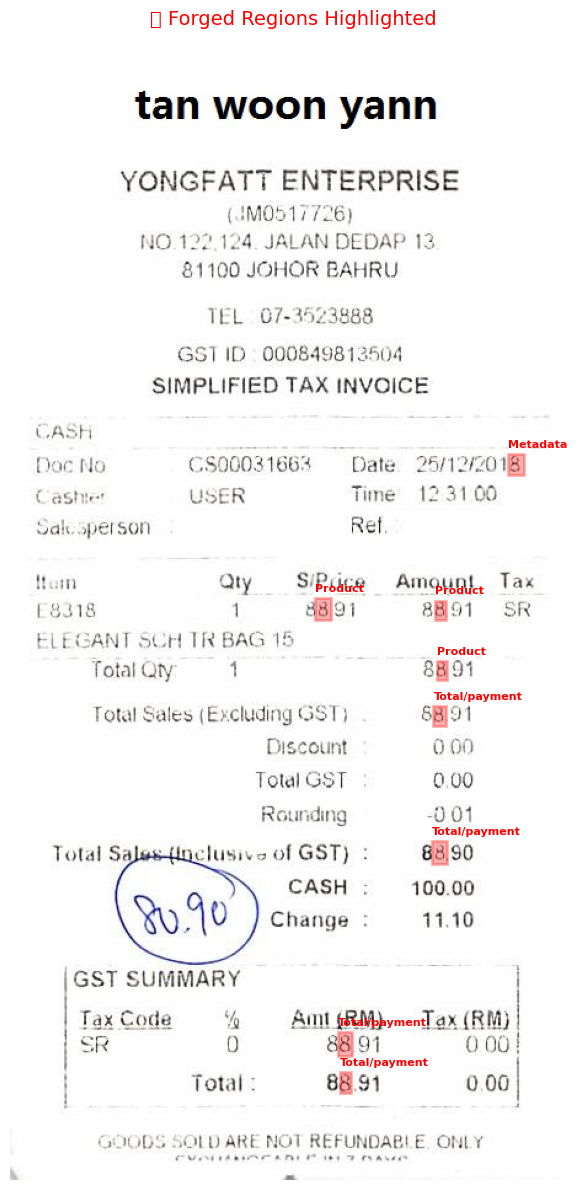


📍 Forged regions found: 8
  → Product | Modified: ['CPI']
  → Metadata | Modified: ['None']
  → Product | Modified: ['CPI']
  → Product | Modified: ['CPI']
  → Total/payment | Modified: ['CPI']
  → Total/payment | Modified: ['CPI']
  → Total/payment | Modified: ['CPI']
  → Total/payment | Modified: ['CPI']


In [9]:
import json
import matplotlib.patches as patches

# Get a forged sample with annotations
forged_with_annotations = train_labels[
    (train_labels['forged'] == 1) &
    (train_labels['forgery annotations'] != '0')
].iloc[0]

img_path = f'{FINDITAGAIN_DIR}/train/{forged_with_annotations["image"]}'
img      = Image.open(img_path)

# Parse annotations
annotations = eval(forged_with_annotations['forgery annotations'])

fig, ax = plt.subplots(1, figsize=(8, 12))
ax.imshow(img)

# Draw bounding boxes on forged regions
for region in annotations['regions']:
    x      = region['shape_attributes']['x']
    y      = region['shape_attributes']['y']
    width  = region['shape_attributes']['width']
    height = region['shape_attributes']['height']
    entity = region['region_attributes'].get('Entity type', 'Unknown')

    rect = patches.Rectangle(
        (x, y), width, height,
        linewidth=2,
        edgecolor='red',
        facecolor='red',
        alpha=0.3
    )
    ax.add_patch(rect)
    ax.text(x, y - 5, entity, color='red', fontsize=8, fontweight='bold')

ax.set_title('🚨 Forged Regions Highlighted', fontsize=14, color='red')
ax.axis('off')
plt.tight_layout()
plt.show()

print(f"\n📍 Forged regions found: {len(annotations['regions'])}")
for r in annotations['regions']:
    print(f"  → {r['region_attributes'].get('Entity type')} | Modified: {list(r['region_attributes'].get('Modified area', {}).keys())}")

In [10]:
print("=" * 45)
print("📊 Find-It-Again EDA Summary")
print("=" * 45)
print(f"Train → Genuine: {train_labels['forged'].value_counts()[0]} | Forged: {train_labels['forged'].value_counts()[1]}")
print(f"Val   → Genuine: {val_labels['forged'].value_counts()[0]}   | Forged: {val_labels['forged'].value_counts()[1]}")
print(f"Test  → Genuine: {test_labels['forged'].value_counts()[0]}  | Forged: {test_labels['forged'].value_counts()[1]}")
print("-" * 45)
print(f"Total images:     {len(train_labels) + len(val_labels) + len(test_labels)}")
print(f"Total forged:     {train_labels['forged'].sum() + val_labels['forged'].sum() + test_labels['forged'].sum()}")
print(f"Total genuine:    {(train_labels['forged']==0).sum() + (val_labels['forged']==0).sum() + (test_labels['forged']==0).sum()}")
print(f"Imbalance ratio:  ~5:1 (genuine:forged)")
print(f"Forgery targets:  Total/payment, Product, Metadata")
print(f"Forgery methods:  Copy-paste (CPI), Digital tampering")
print("=" * 45)
print("\n✅ Find-It-Again EDA Complete!")


📊 Find-It-Again EDA Summary
Train → Genuine: 483 | Forged: 94
Val   → Genuine: 159   | Forged: 34
Test  → Genuine: 183  | Forged: 35
---------------------------------------------
Total images:     988
Total forged:     163
Total genuine:    825
Imbalance ratio:  ~5:1 (genuine:forged)
Forgery targets:  Total/payment, Product, Metadata
Forgery methods:  Copy-paste (CPI), Digital tampering

✅ Find-It-Again EDA Complete!


In [ ]:
summary = {
    "sroie_train_size": len(train_df),
    "sroie_test_size": len(test_df),
    "cord_train_size": len(cord['train']),
    "cord_val_size": len(cord['validation']),
    "cord_test_size": len(cord['test']),
    "sroie_unique_vendors": int(train_df['company'].nunique()),
    "sroie_total_min": float(train_df['total_clean'].min()),
    "sroie_total_max": float(train_df['total_clean'].max()),
    "sroie_total_mean": float(train_df['total_clean'].mean()),
    "sroie_outliers_count": len(outliers),
}



In [ ]:
pprint(summary)

{'cord_test_size': 100,
 'cord_train_size': 800,
 'cord_val_size': 100,
 'sroie_outliers_count': 57,
 'sroie_test_size': 347,
 'sroie_total_max': 7838.8,
 'sroie_total_mean': 67.82173354735153,
 'sroie_total_min': 1.0,
 'sroie_train_size': 625,
 'sroie_unique_vendors': 235}


In [ ]:
os.makedirs(f'{PROJECT_DIR}/notebooks', exist_ok=True)
with open(f'{PROJECT_DIR}/notebooks/eda_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("✅ EDA summary saved to Drive!")
print(json.dumps(summary, indent=2))

✅ EDA summary saved to Drive!
{
  "sroie_train_size": 625,
  "sroie_test_size": 347,
  "cord_train_size": 800,
  "cord_val_size": 100,
  "cord_test_size": 100,
  "sroie_unique_vendors": 235,
  "sroie_total_min": 1.0,
  "sroie_total_max": 7838.8,
  "sroie_total_mean": 67.82173354735153,
  "sroie_outliers_count": 57
}
